## Import Tool and Libraries

In [1]:
import numpy as np
import pandas as pd 
import os
import tensorflow as tf
from tqdm import tqdm

# NLP Imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Embedding, Dense, LSTM, Input, add, Concatenate, Reshape, concatenate, Bidirectional, Dropout

# Model Creation Imports
from tensorflow.keras.models import Sequential, Model

# Computer Vision imports
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import DenseNet201

# Model Learning and Loses Import 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Warning and Visualization Imports
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

2025-06-06 05:17:42.838951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749187063.043789      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749187063.102165      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Image Captioning**



## **What is Image Captioning?**
- Image captioning is the process of generating a textual description of an image. It uses both Natural Language Processing and computer vision to generate the captions.
- This task lies at the intersection of Computer Vision and natural language processing. Most image captioning systems use an encoder decoder framework, where an input image is encoded into an intermediate representation of the information in the image, and then decoded into a descriptive text sequence.


### **CNN + RNNs(LSTMs)**
- To perform Image Captioning we will require two deep learning models combined into one for the training purpose.
- CNNs extract the features from the image of some vector size aka the vector embeddings. The size of these embeddings depend on the type of the pretrained network being used for 

# **Load Dataset**

In [2]:
image_path = '/kaggle/input/flickr8k/Images'
data = pd.read_csv('/kaggle/input/flickr8k/captions.txt')
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


# **Visualization**

- Images and their corresponding captions

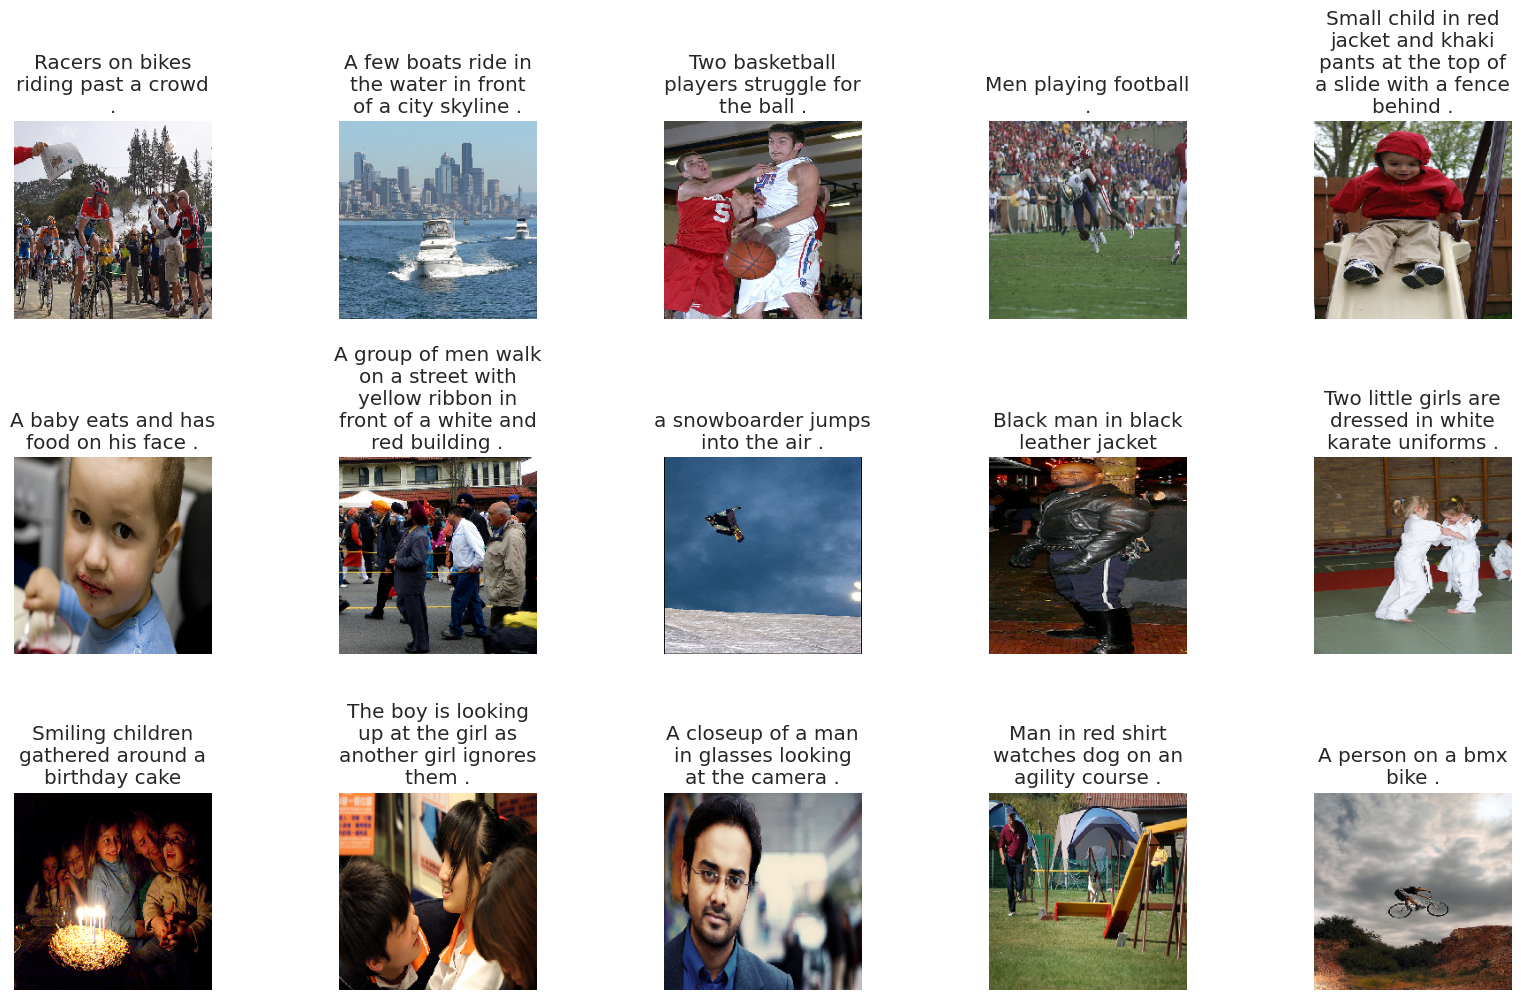

In [3]:
def readImage(path, img_size=224):
    img = load_img(path, color_mode='rgb', target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.  # [0,1]
    
    return img

def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=[20,20])
    n = 0
    for i in range(15):
        n +=1
        plt.subplot(5,5, n)
        plt.subplots_adjust(hspace=0.7, wspace=0.3)
        image = readImage(f"/kaggle/input/flickr8k/Images/{temp_df.image[i]}")
        plt.imshow(image)
        plt.title('\n'.join(wrap(temp_df.caption[i], 20)))
        plt.axis("off")

display_images(data.sample(15))

# **Caption Text Preprocessing Steps**

- Convert sentences into lowercase
- Remove special characters and numbers present in the text
- Remove extra spaces
- Remove single characters
- Add a starting and an ending tag to the sentences to indicate the beginning and ending of the sequence

In [4]:
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].apply(lambda x: x.replace("[^a-zA-Z]",""))
    data['caption'] = data['caption'].apply(lambda x: x.replace("\s+"," "))
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word)>1]))   # skipping the words with single letter (eg. a)
    data['caption'] = "startseq " + data['caption'] + " endseq"
    
    return data

data = text_preprocessing(data)
captions = data['caption'].tolist()
captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tri-colored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [5]:
len(captions)

40455

In [6]:
## You can also go with this code...
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
snowball = SnowballStemmer(language='english')
import re

corpus = []

for i in range(len(data)):
    caption = re.sub("[^a-zA-Z]", " ", data['caption'][i])
    caption = caption.lower()
    caption = caption.split()
    caption = [snowball.stem(word) for word in caption if word not in stopwords.words('english')]
    caption = " ".join(caption)
    caption = "startseq " + caption + " endseq"
    corpus.append(caption)

In [7]:
len(corpus)
corpus[:5]

['startseq startseq child pink dress climb set stair entri way endseq endseq',
 'startseq startseq girl go wooden build endseq endseq',
 'startseq startseq littl girl climb wooden playhous endseq endseq',
 'startseq startseq littl girl climb stair playhous endseq endseq',
 'startseq startseq littl girl pink dress go wooden cabin endseq endseq']

## **Tokenization and encoded Representation**


- The words in a sentence are seperated/tokenized and encoded in a one hot representation. 

In [8]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(captions)

# tokenizer.word_index 
vocab_size = len(tokenizer.word_index) + 1    ## vocabulary_length + 1

max_length = max([len(caption.split()) for caption in captions])

images = data['image'].unique().tolist()
nimages = len(images)

# Splitting for training and validation images
split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

tokenizer.texts_to_sequences([captions[0]])[0]

[1, 42, 3, 89, 171, 6, 118, 50, 392, 11, 393, 3, 27, 5145, 669, 2]

# **Image Feature Extraction**

- DenseNet201 Architecture is used to extract the features from the images
- Any other pretrained architectures can also be used for extracting features from these images
- Since the Global Average Pooling layer is selected as the final layer of the DenseNet201 model for our feature extraction, our images 

In [9]:
model = DenseNet201()

fe = Model(inputs = model.input, outputs = model.layers[-2].output)

img_size = 224
features = {}

for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path, image), target_size=(img_size, img_size))
    img = img_to_array(img)
    img = img/255.
    img = np.expand_dims(img, axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature

I0000 00:00:1749187120.452560      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749187120.453351      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


82524592/82524592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


  0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1749187135.493541     110 service.cc:148] XLA service 0x7f8a340e8000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749187135.494573     110 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749187135.494596     110 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749187137.682123     110 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1749187150.126509     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8091/8091 [15:48<00:00,  8.53it/s]


# **Data Generation/Augmentation**


- Since Image Caption model training like any other neural network is a highly resource utilizing process we cannot load the data into the main hence we need to generate the data in the required format batch wise.
- The inputs will be the image embeddings and their corresponding caption text embeddings for the training process.
- The text embeddings are passed word by word for the caption generation during the inference time.


In [16]:
class CustomDataGenerator(Sequence):
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer,
                vocab_size, max_length, features, shuffle=True):

        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.batch_size = batch_size
        self.directory = directory
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)
        
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
            
    def __len__(self):
        return self.n // self.batch_size

    def __getitem__(self,index):

        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)
        return (X1,X2), y

    def __get_data(self,batch):

        X1, X2, y = list(), list(), list()

        images = batch[self.X_col].tolist()

        for image in images:
            feature = self.features[image][0]
            
            captions = batch.loc[batch[self.X_col]==image, self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
                    
        X1, X2, y = np.array(X1), np.array(X2), np.array(y)

        return X1, X2, y 


train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                    tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                    tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

In [17]:
train_generator[0]

((array([[7.8687910e-05, 7.3524052e-04, 1.1395992e-03, ..., 5.6523514e-01,
          2.2903730e-01, 6.9639802e-01],
         [7.8687910e-05, 7.3524052e-04, 1.1395992e-03, ..., 5.6523514e-01,
          2.2903730e-01, 6.9639802e-01],
         [7.8687910e-05, 7.3524052e-04, 1.1395992e-03, ..., 5.6523514e-01,
          2.2903730e-01, 6.9639802e-01],
         ...,
         [1.9476043e-04, 7.0213026e-04, 1.4947485e-03, ..., 2.7233658e-02,
          5.5759501e-01, 3.8916641e-01],
         [1.9476043e-04, 7.0213026e-04, 1.4947485e-03, ..., 2.7233658e-02,
          5.5759501e-01, 3.8916641e-01],
         [1.9476043e-04, 7.0213026e-04, 1.4947485e-03, ..., 2.7233658e-02,
          5.5759501e-01, 3.8916641e-01]], dtype=float32),
  array([[  0,   0,   0, ...,   0,   0,   1],
         [  0,   0,   0, ...,   0,   1,  42],
         [  0,   0,   0, ...,   1,  42,   3],
         ...,
         [  0,   0,   0, ...,  10,  76,  49],
         [  0,   0,   0, ...,  76,  49,   4],
         [  0,   0,   0, ...,

# **Modelling**

- The image Embedding representations are concatenated with the first word of the sentence ie. starseq and passed to the LSTM network.
- The LSTM networks starts generating words after each input thus forming a sentence at the end.

In [18]:
from tensorflow.keras.utils import plot_model

input1 = Input(shape=(1920,))
input2 = Input(shape=(max_length,))

img_features = Dense(256, activation='relu')(input1)
img_features_reshaped = Reshape((1, 256), input_shape=(256,))(img_features)

sentence_features = Embedding(vocab_size, 256, mask_zero=False)(input2)
merged = concatenate([img_features_reshaped,sentence_features],axis=1)
sentence_features = LSTM(256)(merged)
x = Dropout(0.5)(sentence_features)
x = add([x, img_features])
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(vocab_size, activation='softmax')(x)

caption_model = Model(inputs=[input1,input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy',optimizer='adam')


from tensorflow.keras.callbacks import ModelCheckpoint

# Define the model checkpoint
model_name = "model.keras"  # Update the extension to .keras
checkpoint = ModelCheckpoint(
    model_name,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', 
                                            patience=3, 
                                            verbose=1, 
                                            factor=0.2, 
                                            min_lr=0.00000001)




history = caption_model.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint,earlystopping,learning_rate_reduction])

Epoch 1/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 5.7384
Epoch 1: val_loss improved from inf to 4.31316, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - loss: 5.7373 - val_loss: 4.3132 - learning_rate: 0.0010
Epoch 2/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 4.3722
Epoch 2: val_loss improved from 4.31316 to 4.01159, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 77s 144ms/step - loss: 4.3721 - val_loss: 4.0116 - learning_rate: 0.0010
Epoch 3/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 4.0680
Epoch 3: val_loss improved from 4.01159 to 3.85933, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 76s 142ms/step - loss: 4.0679 - val_loss: 3.8593 - learning_rate: 0.0010
Epoch 4/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 3.8719
Epoch 4: val_loss improved from 3.85933 to 3.76182, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 75s 140ms/step - loss: 3.8718 - val_loss: 3.7618 - learning_rate: 0.0010


# **Learning Curve**

- The model has clearly ovefit, possibly due to less amount of data
- We can tackle this problem in two ways:
    - Train the model on larger dataset Flickr40k
    - Attention Models

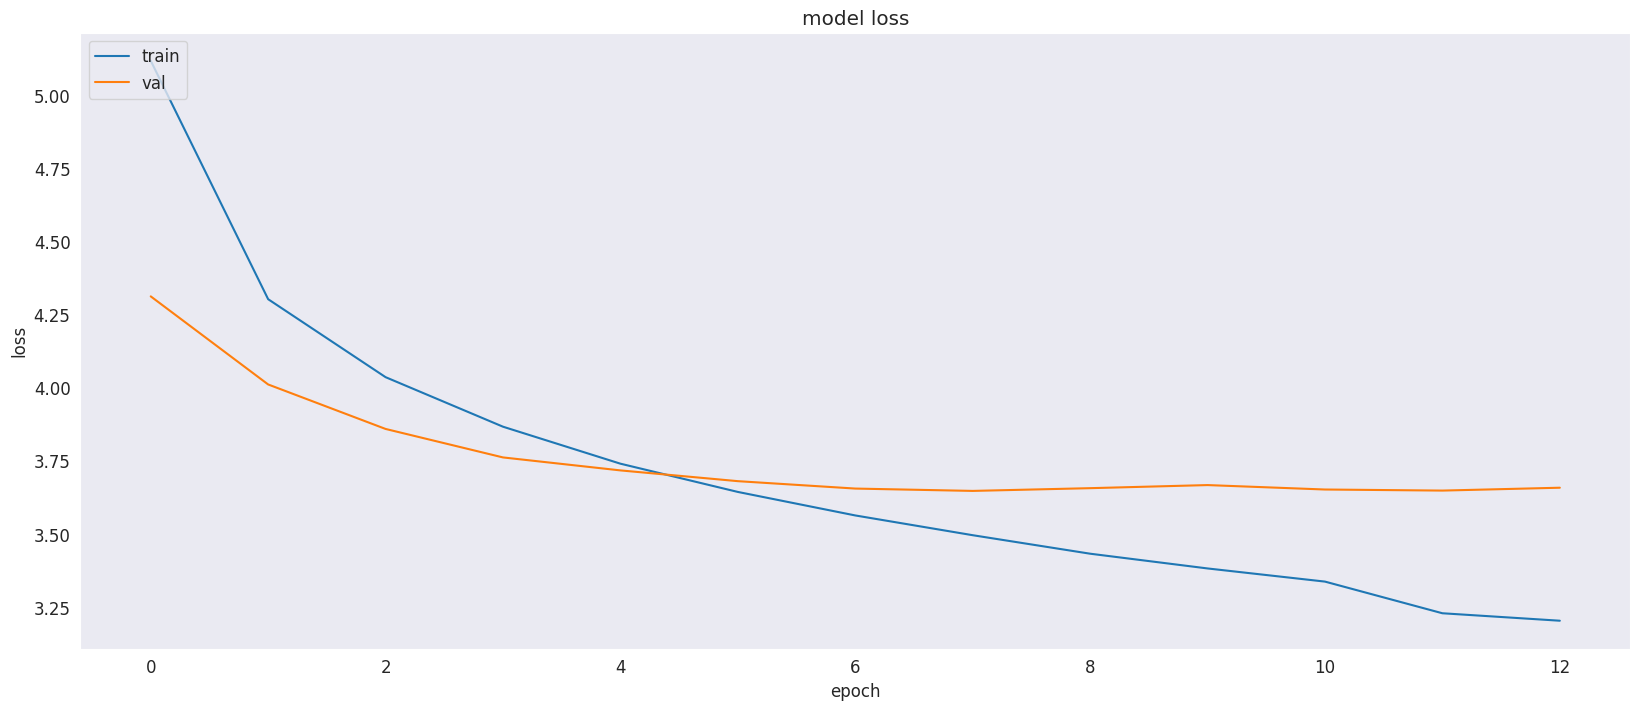

In [19]:
plt.figure(figsize=[20,8])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# **Caption Generation Utility Functions**

- Utility functions to generate the captions of input images at the inference time.
- Here the image embeddings are passed along with the first word, followed by which the text embedding of each new word is passed to generate the next word.

In [20]:
import pickle
pickle.dump(tokenizer, open('tokenizer.pkl', 'wb'))

pickle.dump(fe, open('feature_extractor.pkl', 'wb'))
fe.save("feature_extractor.keras")

In [32]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt 
import pickle

# load save files
model_path = "model.keras"
tokenizer_path = "tokenizer.pkl"
feature_extractor_path = "feature_extractor.keras"

def generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path, max_length=34, img_size=224):
    caption_model = load_model(model_path)
    feature_extractor =  load_model(feature_extractor_path)

    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)
    
    # preprocess and read_img:
    img = load_img(image_path, target_size=(img_size,img_size))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    image_features = feature_extractor.predict(img, verbose=0)

    # generate caption for this image
    in_text = "startseq"
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = caption_model.predict([image_features, sequence], verbose=0)
        yhat_index = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat_index, None)
        if word is None:
            break
        in_text += " " + word
        if word == 'endseq':
            break
    caption = in_text.replace('startseq', '').replace("endseq",'').strip()

    # display image with caption
    img = load_img(image_path, target_size=(img_size,img_size))
    plt.figure(figsize=[8,8])
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=16, color='blue')
    plt.show()
    

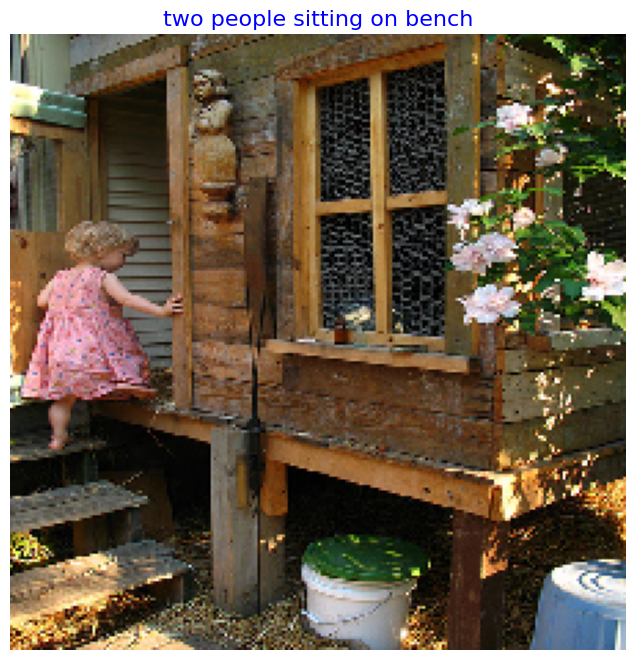

In [33]:
## Example Usage 
image_path = '/kaggle/input/flickr8k/Images/1000268201_693b08cb0e.jpg'   # Replace with the path to the input image
generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)

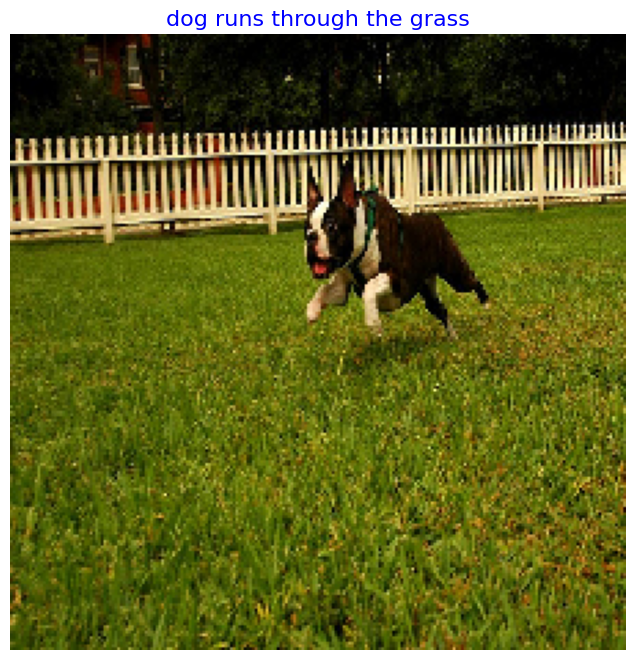

In [35]:
## Example Usage 
image_path = '/kaggle/input/flickr8k/Images/1009434119_febe49276a.jpg'  # Replace with the path to the input image
generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)